In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [96]:
df = pd.read_csv('monthly_sales.csv')

df.head()

,Date,Sales
0,2021-01-31,120
1,2021-02-28,123
2,2021-03-31,126
3,2021-04-30,125
4,2021-05-31,130


In [97]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [98]:
df.head()

,Sales
Date,
2021-01-31,120
2021-02-28,123
2021-03-31,126
2021-04-30,125
2021-05-31,130


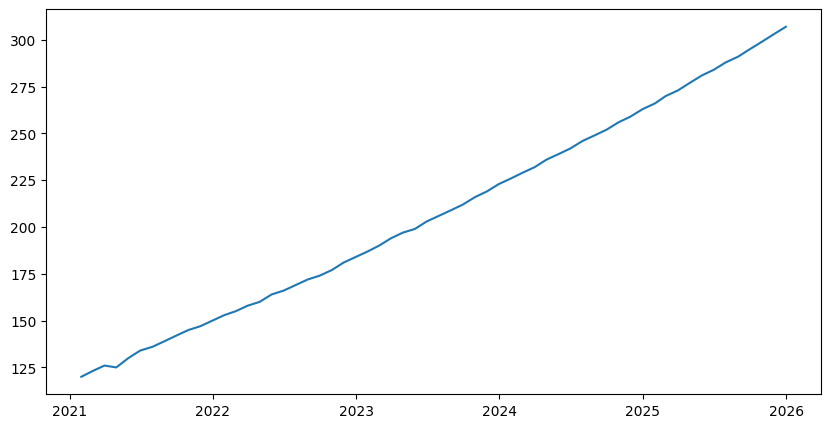

In [99]:
plt.figure(figsize=(10,5))

plt.plot(df['Sales'])
plt.show()

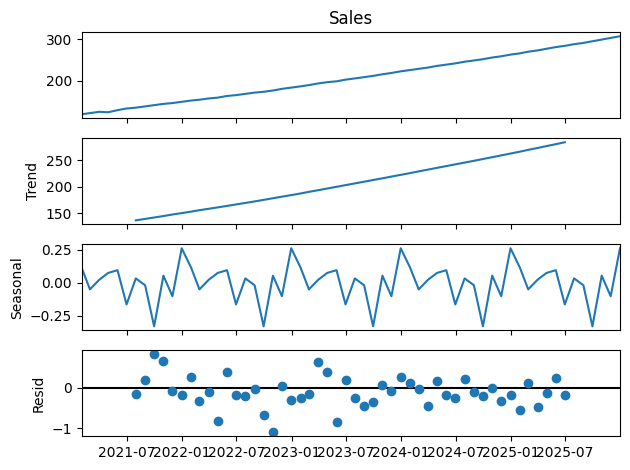

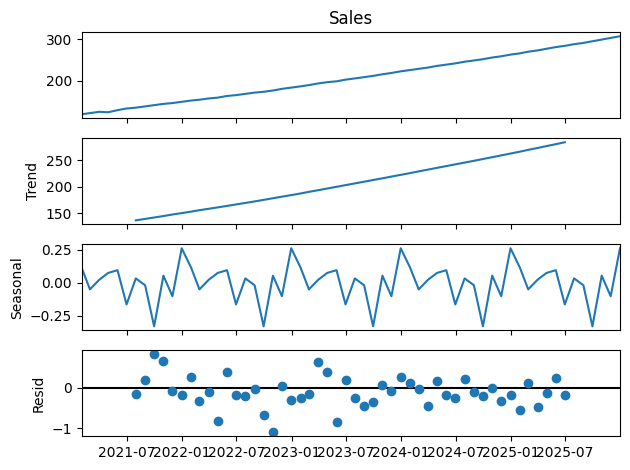

In [100]:
from statsmodels.tsa.seasonal import seasonal_decompose 

decompose = seasonal_decompose(
    df['Sales'],
    model='additive',
    period=12,

)

decompose.plot()

In [101]:
from statsmodels.tsa.stattools import adfuller 

results = adfuller(df['Sales'])

print(results[1])

1.0


In [102]:
if results[1]<0.05:
    print('Stationary')
else:
    print('Not Stationary')

Not Stationary


In [103]:
df['Sales_diff'] = df['Sales'].diff()

df_diff = df['Sales_diff'].dropna()

results = adfuller(df_diff)

print(results[1])

0.8805712715370037


In [104]:
df['Sales_diff2'] = df['Sales_diff'].diff()

df_diff2 = df['Sales_diff2'].dropna()

results = adfuller(df_diff2)

print(results[1])

1.2132257627393231e-14


In [105]:
if results[1] < 0.05:
    print('Stationary')
else:
    print('Non Stationary')

Stationary


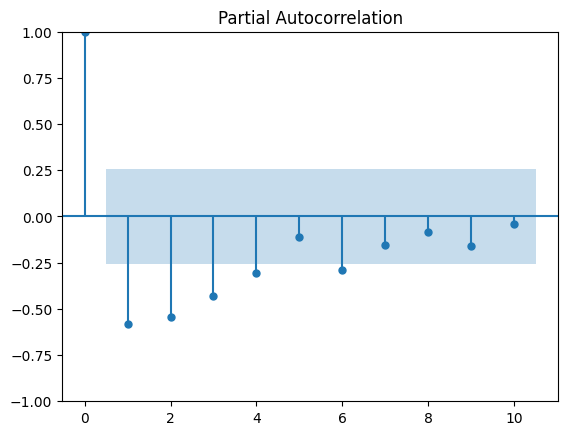

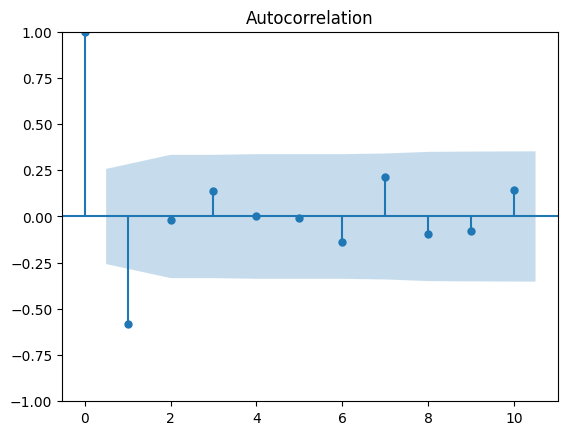

In [106]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf 

plot_pacf(df_diff2, lags=10)
plot_acf(df_diff2, lags=10)

plt.show()

In [107]:
train = df.iloc[:-6]
test = df.iloc[-6:]

In [108]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['Sales'], order=(1,2,1))
model_fit = model.fit()

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [109]:
forecast = model_fit.forecast(steps=len(test))
forecast

2025-07-31    287.622667
2025-08-31    291.021390
2025-09-30    294.500655
2025-10-31    297.950953
2025-11-30    301.411669
2025-12-31    304.868638
Freq: ME, Name: predicted_mean, dtype: float64

In [110]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

mae = mean_absolute_error(test['Sales'], forecast)
rmse = np.sqrt(mean_squared_error(test['Sales'], forecast))
print(mae)
print(rmse)

0.9444680273158212
1.194304755621303


In [111]:
plt.figure(figsize=(12,6))


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

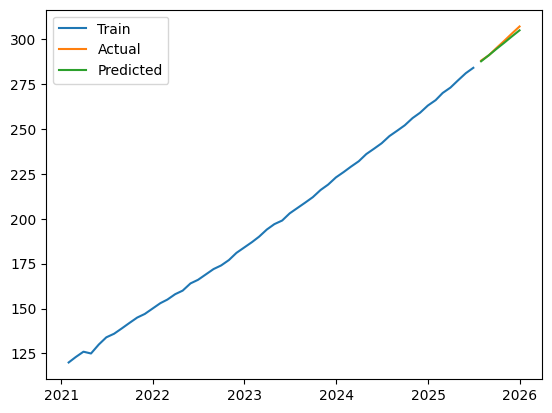

In [112]:

plt.plot(train.index, train['Sales'], label='Train')
plt.plot(test.index, test['Sales'], label='Actual')
plt.plot(test.index, forecast, label='Predicted')

plt.legend()
plt.show()